# 🤖 Model 2: TF-IDF + SVM — Phát hiện Tin Giả Tiếng Việt


In [2]:
!pip install -q underthesea scikit-learn pandas openpyxl matplotlib seaborn scipy

## 📦 Bước 1 — Import thư viện

In [3]:
import re
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
warnings.filterwarnings("ignore")

from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)
from sklearn.preprocessing import StandardScaler

# Tách từ tiếng Việt
try:
    from underthesea import word_tokenize
    USE_UNDERTHESEA = True
    print("✅ underthesea sẵn sàng — dùng tách từ tiếng Việt chuẩn")
except ImportError:
    USE_UNDERTHESEA = False
    print("⚠️  Không có underthesea — dùng split() thường (kết quả kém hơn một chút)")

print("✅ Import xong!")

✅ underthesea sẵn sàng — dùng tách từ tiếng Việt chuẩn
✅ Import xong!


## 📂 Bước 2 — Đọc dữ liệu
Dataset của nhóm đã được chia sẵn thành 3 file:
- `train.csv` — dùng để **train** model
- `val.csv` — dùng để **theo dõi** trong lúc train
- `test.csv` — dùng để **đánh giá cuối cùng**

In [4]:
# Đổi đường dẫn nếu file để ở folder khác
TRAIN_PATH = "train.csv"
VAL_PATH   = "val.csv"
TEST_PATH  = "test.csv"

train = pd.read_csv(TRAIN_PATH)
val   = pd.read_csv(VAL_PATH)
test  = pd.read_csv(TEST_PATH)

print(f"Train : {len(train):,} rows")
print(f"Val   : {len(val):,} rows")
print(f"Test  : {len(test):,} rows")
print()
print("Label distribution (train):", train['label'].value_counts().to_dict())
print("Label distribution (val)  :", val['label'].value_counts().to_dict())
print("Label distribution (test) :", test['label'].value_counts().to_dict())
print()
print("Columns:", train.columns.tolist())

Train : 10,417 rows
Val   : 2,232 rows
Test  : 2,233 rows

Label distribution (train): {'REAL': 6747, 'FAKE': 3670}
Label distribution (val)  : {'REAL': 1446, 'FAKE': 786}
Label distribution (test) : {'REAL': 1446, 'FAKE': 787}

Columns: ['id', 'title', 'content', 'text', 'source', 'url', 'publish_date', 'topic', 'label', 'explanation', 'text_length', 'title_length', 'uppercase_ratio', 'exclamation_count', 'question_count', 'clickbait_score', 'sentiment_score', 'label_id']


## 🧹 Bước 3 — Tiền xử lý văn bản
Các bước xử lý:
1. Lowercase toàn bộ text
2. Bỏ URL, ký tự đặc biệt
3. Tách từ tiếng Việt (underthesea) và bỏ stopwords

> 💡 Dataset đã có sẵn cột `text` = title + content ghép lại — không cần tự ghép như version cũ nữa!

In [5]:
STOPWORDS_VI = {
    "và", "của", "là", "có", "trong", "được", "với", "cho", "các",
    "này", "đó", "không", "để", "một", "những", "như", "từ", "theo",
    "khi", "về", "tại", "hay", "hoặc", "đã", "sẽ", "đang", "bị",
    "vì", "mà", "nên", "thì", "cũng", "lại", "rất", "còn", "hơn",
    "sau", "trước", "trên", "dưới", "đến", "ra", "vào", "lên", "xuống",
}

def clean_text(text: str) -> str:
    if pd.isna(text):
        return ""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)   # bỏ URL
    text = re.sub(r"[^\w\s]", " ", text)            # bỏ ký tự đặc biệt
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize_vi(text: str) -> str:
    if USE_UNDERTHESEA:
        tokens = word_tokenize(text, format="text").split()
    else:
        tokens = text.split()
    return " ".join(t for t in tokens if t not in STOPWORDS_VI and len(t) > 1)

def preprocess(text: str) -> str:
    return tokenize_vi(clean_text(text))

print("Đang xử lý văn bản (có thể mất 1-2 phút)...")
for df in [train, val, test]:
    df["text_processed"] = df["text"].apply(preprocess)
print("✅ Tiền xử lý xong!")
print("Ví dụ:")
print("  Gốc  :", train['text'].iloc[0][:80])
print("  Sau xử lý:", train['text_processed'].iloc[0][:80])

Đang xử lý văn bản (có thể mất 1-2 phút)...
✅ Tiền xử lý xong!
Ví dụ:
  Gốc  : 6 gương mặt sáng giá cho giải 'Nobel Toán học' 2026 1. Hong Wang Wang, sinh năm 
  Sau xử lý: gương_mặt sáng giá giải nobel_toán học 2026 hong wang wang sinh năm 1991 cái tên


## 🔢 Bước 4 — Chuẩn bị features
Model v2 dùng **2 loại features** kết hợp:

| Loại | Features | Mô tả |
|---|---|---|
| **TF-IDF** | 15.000 features | Trọng số từ trong văn bản |
| **Numeric** | 5 features | clickbait_score, sentiment_score, uppercase_ratio, exclamation_count, question_count |

Ghép 2 loại lại → ma trận đầu vào cho SVM

In [6]:
NUMERIC_FEATURES = [
    "clickbait_score",    # độ clickbait của tiêu đề (0 - 0.6)
    "sentiment_score",    # cảm xúc bài viết (-1 đến 1)
    "uppercase_ratio",    # tỉ lệ chữ hoa (dấu hiệu giật gân)
    "exclamation_count",  # số dấu chấm than
    "question_count",     # số dấu hỏi
]

X_train_text = train["text_processed"]
X_val_text   = val["text_processed"]
X_test_text  = test["text_processed"]

X_train_num = train[NUMERIC_FEATURES].fillna(0).values
X_val_num   = val[NUMERIC_FEATURES].fillna(0).values
X_test_num  = test[NUMERIC_FEATURES].fillna(0).values

y_train = train["label_id"]
y_val   = val["label_id"]
y_test  = test["label_id"]

print("Label encoding: REAL=0, FAKE=1")
print(f"Numeric features: {NUMERIC_FEATURES}")

Label encoding: REAL=0, FAKE=1
Numeric features: ['clickbait_score', 'sentiment_score', 'uppercase_ratio', 'exclamation_count', 'question_count']


## 🔤 Bước 5 — TF-IDF Vectorization

In [7]:
# TF-IDF: chuyển text thành vector số
# - max_features=15000: giữ top 15k từ quan trọng nhất
# - ngram_range=(1,2): dùng cả unigram (1 từ) và bigram (2 từ liền nhau)
# - sublinear_tf=True: dùng log(TF) thay TF thô để giảm ảnh hưởng từ lặp nhiều
tfidf = TfidfVectorizer(
    max_features=15000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
)

X_train_tfidf = tfidf.fit_transform(X_train_text)  # fit chỉ trên train!
X_val_tfidf   = tfidf.transform(X_val_text)
X_test_tfidf  = tfidf.transform(X_test_text)

print(f"TF-IDF matrix (train): {X_train_tfidf.shape}")

# Chuẩn hóa numeric features (StandardScaler)
scaler = StandardScaler()
X_train_num_s = scaler.fit_transform(X_train_num)
X_val_num_s   = scaler.transform(X_val_num)
X_test_num_s  = scaler.transform(X_test_num)

# Ghép TF-IDF + numeric
X_train_final = sp.hstack([X_train_tfidf, sp.csr_matrix(X_train_num_s)])
X_val_final   = sp.hstack([X_val_tfidf,   sp.csr_matrix(X_val_num_s)])
X_test_final  = sp.hstack([X_test_tfidf,  sp.csr_matrix(X_test_num_s)])

print(f"Final feature matrix (train): {X_train_final.shape}")
print(f"  → {X_train_tfidf.shape[1]:,} TF-IDF + {len(NUMERIC_FEATURES)} numeric features")

TF-IDF matrix (train): (10417, 15000)
Final feature matrix (train): (10417, 15005)
  → 15,000 TF-IDF + 5 numeric features


## 🏋️ Bước 6 — Train SVM
**SVM (Support Vector Machine)** tìm siêu phẳng phân tách REAL và FAKE sao cho margin lớn nhất.

- `kernel='linear'` — phù hợp với text data (TF-IDF tạo ra không gian nhiều chiều thưa)
- `C=1.0` — điều chỉnh độ rộng margin (C lớn → fit chặt hơn, dễ overfit)
- `class_weight='balanced'` — tự điều chỉnh khi REAL nhiều hơn FAKE

In [8]:
svm = SVC(
    kernel="linear",
    C=1.0,
    probability=True,
    class_weight="balanced",
    random_state=42,
)

print("Đang train SVM (khoảng 2-3 phút)...")
svm.fit(X_train_final, y_train)
print("✅ Train xong!")

Đang train SVM (khoảng 2-3 phút)...
✅ Train xong!


## 📊 Bước 7 — Đánh giá

In [9]:
def evaluate(X, y_true, split_name):
    y_pred  = svm.predict(X)
    y_proba = svm.predict_proba(X)[:, 1]
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_proba)
    print(f"\n── {split_name} ──────────────────────")
    print(f"Accuracy : {acc:.4f}")
    print(f"ROC-AUC  : {auc:.4f}")
    print(classification_report(y_true, y_pred, target_names=["REAL", "FAKE"]))
    return y_pred, y_proba, acc, auc

_, _,           val_acc,  val_auc  = evaluate(X_val_final,  y_val,  "Validation")
y_pred, y_prob, test_acc, test_auc = evaluate(X_test_final, y_test, "Test")


── Validation ──────────────────────
Accuracy : 0.9637
ROC-AUC  : 0.9930
              precision    recall  f1-score   support

        REAL       0.97      0.97      0.97      1446
        FAKE       0.95      0.94      0.95       786

    accuracy                           0.96      2232
   macro avg       0.96      0.96      0.96      2232
weighted avg       0.96      0.96      0.96      2232


── Test ──────────────────────
Accuracy : 0.9498
ROC-AUC  : 0.9875
              precision    recall  f1-score   support

        REAL       0.96      0.96      0.96      1446
        FAKE       0.92      0.94      0.93       787

    accuracy                           0.95      2233
   macro avg       0.94      0.95      0.95      2233
weighted avg       0.95      0.95      0.95      2233



## 📈 Bước 8 — Vẽ biểu đồ

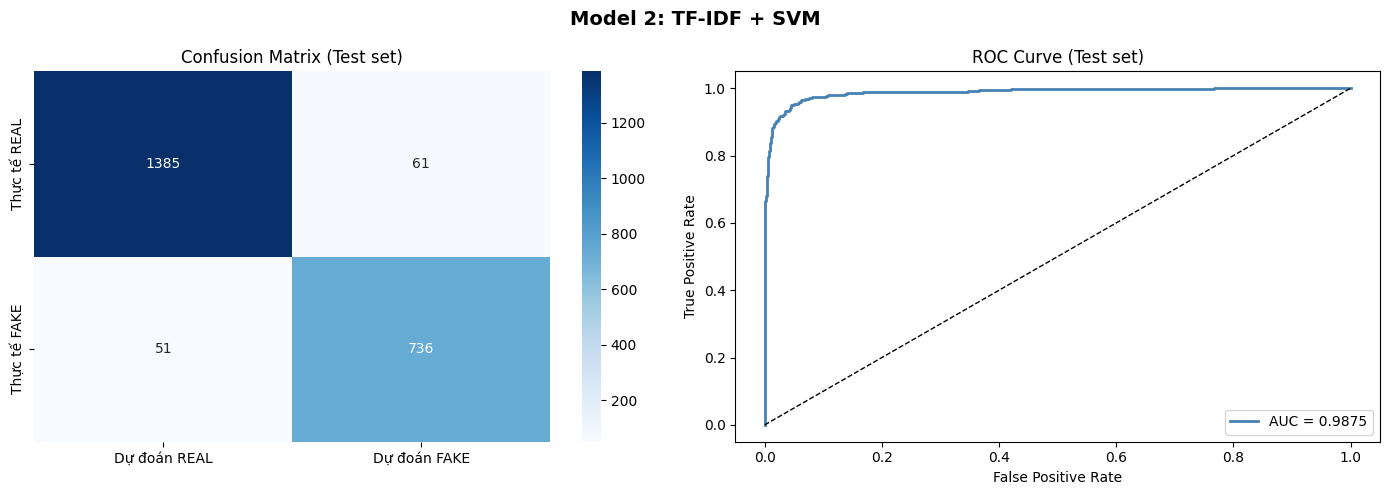

✅ Biểu đồ đã lưu: model2_svm_results.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Model 2: TF-IDF + SVM", fontsize=14, fontweight="bold")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Dự đoán REAL", "Dự đoán FAKE"],
            yticklabels=["Thực tế REAL", "Thực tế FAKE"], ax=axes[0])
axes[0].set_title("Confusion Matrix (Test set)")

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color="steelblue", lw=2, label=f"AUC = {test_auc:.4f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve (Test set)")
axes[1].legend()

plt.tight_layout()
plt.savefig("model2_svm_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Biểu đồ đã lưu: model2_svm_results.png")

## 🔍 Bước 9 — Dự đoán bài báo mới

In [11]:
def predict_article(title, content, clickbait_score=0.0,
                    sentiment_score=0.0, uppercase_ratio=0.0,
                    exclamation_count=0, question_count=0):
    text = title + " " + content
    text_proc = preprocess(text)
    tfidf_vec = tfidf.transform([text_proc])
    num_vec   = scaler.transform([[clickbait_score, sentiment_score,
                                   uppercase_ratio, exclamation_count,
                                   question_count]])
    final_vec = sp.hstack([tfidf_vec, sp.csr_matrix(num_vec)])
    pred  = svm.predict(final_vec)[0]
    proba = svm.predict_proba(final_vec)[0]
    label = "FAKE 🚨" if pred == 1 else "REAL ✅"
    print(f"{label}  (REAL: {proba[0]*100:.1f}% | FAKE: {proba[1]*100:.1f}%)")
    print(f"Tiêu đề: {title[:80]}")

# Thử với 2 bài mẫu
predict_article(
    title="WHO xác nhận vaccine COVID-19 an toàn và hiệu quả",
    content="Tổ chức Y tế Thế giới công bố báo cáo vaccine ngăn ngừa tử vong.",
    clickbait_score=0.0, sentiment_score=0.5,
)
print()
predict_article(
    title="TIẾT LỘ SỐC: Uống nước chanh chữa ung thư 100%!!!",
    content="Bí quyết từ thầy lang bí ẩn ở Tây Nguyên được giấu kín hàng chục năm.",
    clickbait_score=0.6, sentiment_score=-0.8,
    uppercase_ratio=0.15, exclamation_count=3,
)

REAL ✅  (REAL: 95.9% | FAKE: 4.1%)
Tiêu đề: WHO xác nhận vaccine COVID-19 an toàn và hiệu quả

FAKE 🚨  (REAL: 3.7% | FAKE: 96.3%)
Tiêu đề: TIẾT LỘ SỐC: Uống nước chanh chữa ung thư 100%!!!
